### Data Extraction

In [21]:
import pandas as pd
import os

# === Step 1: Define file paths ===
base_path = "../../Results/Data/NEW/Metrics_By_MCS"
file_names = sorted([
    "MCS_0.csv", "MCS_100.csv", "MCS_200.csv", "MCS_300.csv",
    "MCS_400.csv", "MCS_500.csv", "MCS_600.csv", "MCS_700.csv"
])

# === Step 2: Load and concatenate all MCS data ===
dfs = []
for file_name in file_names:
    mcs_value = int(file_name.split('_')[1].split('.')[0])
    file_path = os.path.join(base_path, file_name)
    df = pd.read_csv(file_path)
    df["MCS"] = mcs_value
    dfs.append(df)

# Combine into a single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

# === Step 3: Define phenotype classification rules ===
def classify_phenotype(row):
    invasive_area = row["Invasive Area"]
    infiltrative_area = row["Infiltrative Area"]
    branches = row["Fingers"]
    single_defect = row["Single Defects"]
    clusters = row["Clusters"]

    if invasive_area == infiltrative_area and branches == 0 and single_defect == 0 and clusters == 0:
        return "No invasion"
    elif invasive_area < infiltrative_area and branches == 0 and single_defect > 0 and clusters == 0:
        return "Single cell invasion"
    elif invasive_area == infiltrative_area and branches > 0 and single_defect == 0 and clusters == 0:
        return "Bulk invasion"
    elif invasive_area < infiltrative_area and branches > 0 and single_defect > 0 and clusters >= 0:
        return "Multimodal invasion"
    else:
        return "Unclassified"

# === Step 4: Apply classification to each row ===
combined_df["Phenotype"] = combined_df.apply(classify_phenotype, axis=1)

# Optional: Remove "Unclassified" rows
combined_df = combined_df[combined_df["Phenotype"] != "Unclassified"].reset_index(drop=True)

# === Step 5: Save the labeled data to CSV ===
output_file = "../../Results/Data/NEW/phenotype_classification_over_time.csv"
combined_df.to_csv(output_file, index=False)

print(f"Phenotype classification saved to: {output_file}")


Phenotype classification saved to: ../../Results/Data/NEW/phenotype_classification_over_time.csv


In [ ]:
import pandas as pd
import os

# === Step 1: Load MCS Data ===
base_path = "../../Results/Data/NEW/Metrics_By_MCS"
file_names = sorted([
    "MCS_0.csv", "MCS_100.csv", "MCS_200.csv", "MCS_300.csv",
    "MCS_400.csv", "MCS_500.csv", "MCS_600.csv", "MCS_700.csv"
])

dfs = []
for file_name in file_names:
    mcs_value = int(file_name.split('_')[1].split('.')[0])
    file_path = os.path.join(base_path, file_name)
    df = pd.read_csv(file_path)
    df["MCS"] = mcs_value
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

# === Step 2: Define Phenotype Classification ===
def classify_phenotype(row):
    branches = row["Fingers"]
    single_defect = row["Single Defects"]
    clusters = row["Clusters"]

    if (branches == 0 or branches == 1) and single_defect == 0 and clusters == 0:
        return "No invasion"
    elif (branches == 0 or branches == 1) and single_defect > 0 and clusters == 0:
        return "Single cell invasion"
    elif branches > 0 and single_defect == 0 and clusters == 0:
        return "Bulk invasion"
    elif branches > 0 and single_defect >= 0 and clusters >= 0:
        return "Multimodal invasion"
    else:
        return "Unclassified"

# === Step 3: Apply Phenotype Classification ===
combined_df["Phenotype"] = combined_df.apply(classify_phenotype, axis=1)

# === Step 4: Filter and Group ===
group_cols = ["Contact Energy", "Chemotaxis Lambda", "Proliferative Probability", "MCS", "Phenotype"]
df_filtered = combined_df[group_cols]

phenotype_counts = df_filtered.groupby(group_cols).size().reset_index(name="Count")

# === Step 5: Normalize for Probability ===
phenotype_counts["Total"] = phenotype_counts.groupby(
    ["Contact Energy", "Chemotaxis Lambda", "Proliferative Probability", "MCS"]
)["Count"].transform("sum")
phenotype_counts["Probability"] = phenotype_counts["Count"] / phenotype_counts["Total"]

# === Step 6: Sort by MCS, then Parameters ===
phenotype_probs = phenotype_counts[
    ["MCS", "Contact Energy", "Chemotaxis Lambda", "Proliferative Probability", "Phenotype", "Probability"]
].sort_values(by=["MCS", "Contact Energy", "Chemotaxis Lambda", "Proliferative Probability"]).reset_index(drop=True)

# === Step 7: Save to CSV ===
output_file = "../../Results/Data/NEW/phenotype_probability_map.csv"
phenotype_probs.to_csv(output_file, index=False)

print(f"Phenotype probability map (sorted by MCS → parameters) saved to: {output_file}")


Phenotype probability map (sorted by MCS → parameters) saved to: ../../Results/Data/NEW/phenotype_probability_map.csv


### 2D and 3D Invasion Metric Plots

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

# Load uploaded CSV
df_time = pd.read_csv("../../Results/Data/NEW/phenotype_classification_over_time.csv")

# Assume metrics exist at each MCS step (e.g., Invasive Area, Fingers, etc.)
# Group the time-resolved data
mcs_values = sorted(df_time["MCS"].unique())

# Directory to save plots
output_dir = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/Over_Time/invasion_metric_plots_over_time"
os.makedirs(output_dir, exist_ok=True)

# Metrics to plot (assumed from original list)
metrics = [
    ("Invasive Area", "Invasive Area"),
    ("Infiltrative Area", "Infiltrative Area"),
    ("Single Defects", "Single Defects"),
    ("Fingers", "Fingers"),
    ("Clusters", "Clusters")
]

# Function to process one metric at one MCS step
def process_metric_at_mcs(df, mcs, feature_column, label_name):
    df_mcs = df[df["MCS"] == mcs]
    x = df_mcs["Contact Energy"].values
    y = df_mcs["Chemotaxis Lambda"].values
    z = df_mcs["Proliferative Probability"].values
    c = df_mcs[feature_column].values

    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    z_min, z_max = z.min(), z.max()

    X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
    Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
    X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    grid_points = np.array([x, y, z]).T
    C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())
    C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())
    C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())

    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111, projection='3d')
    colormap = cm.turbo
    norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())

    ax.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap(norm(C_left)), edgecolor='none', alpha=1.0)
    ax.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap(norm(C_right)), edgecolor='none', alpha=1.0)
    ax.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap(norm(C_top)), edgecolor='none', alpha=1.0)

    ax.set_xlabel("Contact Energy", fontsize=10)
    ax.set_ylabel("Migration Coefficient", fontsize=10)
    ax.set_zlabel("Proliferative Probability", fontsize=10)
    ax.view_init(elev=30, azim=40)
    fig.colorbar(cm.ScalarMappable(norm=norm, cmap=colormap), ax=ax, shrink=0.6, aspect=10, pad=0.05).set_label(label_name)

    fname = f"{feature_column.replace(' ', '_')}_3D_MCS_{mcs}.png"
    fpath = os.path.join(output_dir, fname)
    plt.tight_layout()
    plt.savefig(fpath, dpi=300)
    plt.close()
    return fpath

# Generate all plots
all_plot_paths = []
for mcs in mcs_values:
    for feature_column, label in metrics:
        plot_path = process_metric_at_mcs(df_time, mcs, feature_column, label)
        all_plot_paths.append(plot_path)




In [56]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# === Load Data ===
csv_path = "../../Results/Data/NEW/phenotype_classification_over_time.csv" 
df = pd.read_csv(csv_path)

# === Metrics and MCS ===
metrics = [
    ("Invasive Area", "Invasive Area"),
    ("Infiltrative Area", "Infiltrative Area"),
    ("Single Defects", "Single Defects"),
    ("Fingers", "Fingers"),
    ("Clusters", "Clusters")
]
mcs_values = sorted(df["MCS"].unique())
output_dir = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/Over_Time/invasion_metric_plots_over_time"
os.makedirs(output_dir, exist_ok=True)

# === Plotting Function ===
def create_single_3d_plot(df_mcs, feature_column, ax, colormap):
    x = df_mcs["Contact Energy"].values
    y = df_mcs["Chemotaxis Lambda"].values
    z = df_mcs["Proliferative Probability"].values
    c = df_mcs[feature_column].values

    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    z_min, z_max = z.min(), z.max()

    X, Z = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(z_min, z_max, 50))
    Y, _ = np.meshgrid(np.linspace(y_min, y_max, 50), np.linspace(z_min, z_max, 50))
    X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(y_min, y_max, 50))

    points = np.array([x, y, z]).T
    norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())

    C_left = griddata(points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())
    C_right = griddata(points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())
    C_top = griddata(points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())

    ax.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap(norm(C_left)), edgecolor='none', alpha=1.0)
    ax.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap(norm(C_right)), edgecolor='none', alpha=1.0)
    ax.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap(norm(C_top)), edgecolor='none', alpha=1.0)

    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_box_aspect([1,1,1])
    ax.view_init(elev=30, azim=40)

# === Generate Plots for Each Metric Across Time ===
for feature_column, label in metrics:
    fig, axes = plt.subplots(1, len(mcs_values), figsize=(len(mcs_values)*4, 5), subplot_kw={'projection': '3d'})
    colormap = cm.turbo

    for i, mcs in enumerate(mcs_values):
        df_mcs = df[df["MCS"] == mcs]
        ax = axes[i]
        create_single_3d_plot(df_mcs, feature_column, ax, colormap)
        ax.set_title(f"MCS {mcs}", fontsize=10)

    fig.suptitle(label, fontsize=14, weight='bold')
    plt.tight_layout()
    output_path = os.path.join(output_dir, f"{feature_column.replace(' ', '_')}_row.png")
    plt.savefig(output_path, dpi=300)
    plt.close()


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.cm as cm

# === Load Data ===
csv_path = "../../Results/Data/NEW/phenotype_classification_over_time.csv" 
df = pd.read_csv(csv_path)

# === Metrics and MCS ===
metrics = [
    ("Invasive Area", "Invasive Area"),
    ("Infiltrative Area", "Infiltrative Area"),
    ("Single Defects", "Single Defects"),
    ("Fingers", "Fingers"),
    ("Clusters", "Clusters")
]
mcs_values = sorted(df["MCS"].unique())
output_dir = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/Over_Time/2D_contour_metric_rows"  
os.makedirs(output_dir, exist_ok=True)

# === Pick fixed Z (Proliferative Probability) slice to contour in 2D
z_target = df["Proliferative Probability"].median()

# === Plot Function ===
def create_2d_contour(ax, subset, feature_column, vmin, vmax):
    X, Y = np.meshgrid(
        np.linspace(subset["Contact Energy"].min(), subset["Contact Energy"].max(), 100),
        np.linspace(subset["Chemotaxis Lambda"].min(), subset["Chemotaxis Lambda"].max(), 100)
    )
    Z = griddata(
        (subset["Contact Energy"], subset["Chemotaxis Lambda"]),
        subset[feature_column],
        (X, Y),
        method='cubic'
    )
    contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo', vmin=vmin, vmax=vmax)
    ax.set_xticks([]); ax.set_yticks([])
    return contour

# === Generate Contour Rows for Each Metric ===
for feature_column, label in metrics:
    fig, axes = plt.subplots(1, len(mcs_values), figsize=(len(mcs_values)*4, 4))
    
    # Compute global vmin/vmax to normalize colormap across MCS
    all_vals = df[feature_column].values
    vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

    for i, mcs in enumerate(mcs_values):
        df_mcs = df[(df["MCS"] == mcs) & (np.isclose(df["Proliferative Probability"], z_target, atol=0.05))]
        if df_mcs.empty:
            continue
        ax = axes[i]
        contour = create_2d_contour(ax, df_mcs, feature_column, vmin, vmax)
        ax.set_title(f"MCS {mcs}", fontsize=10)

    # Colorbar and save
    cbar = fig.colorbar(contour, ax=axes.ravel().tolist(), shrink=0.8, pad=0.02)
    cbar.set_label(label, fontsize=12)
    fig.suptitle(label + f" at Proliferative Prob ≈ {z_target:.2f}", fontsize=14, weight='bold')
    plt.tight_layout()
    output_path = os.path.join(output_dir, f"{feature_column.replace(' ', '_')}_2D_contour_row.png")
    plt.savefig(output_path, dpi=300)
    plt.close()


/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_19300/1112056124.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


### Phenotype Plots

#### 3D

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.patches import Patch
from matplotlib.font_manager import FontProperties
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import seaborn as sns

from PIL import Image

# Optional video helpers (robust fallbacks)
try:
    import imageio.v2 as imageio
    HAS_IMAGEIO = True
except Exception:
    imageio = None
    HAS_IMAGEIO = False

from matplotlib import animation
def _ffmpeg_available() -> bool:
    try:
        return animation.writers.is_available("ffmpeg")
    except Exception:
        return False

# === Load Data ===
file_path = "../../Results/Data/NEW/phenotype_probability_map.csv"
df = pd.read_csv(file_path)

# === Define phenotype color mapping (colorblind-friendly palette) ===
cb_palette = sns.color_palette("colorblind")
phenotype_colors = {
    "No invasion": cb_palette[2],           # sky blue
    "Single cell invasion": cb_palette[0],  # blue
    "Bulk invasion": cb_palette[1],         # orange
    "Multimodal invasion": cb_palette[3]    # gold
}

# === Grid resolution ===
N = 40
x_vals = np.linspace(df["Contact Energy"].min(), df["Contact Energy"].max(), N)
y_vals = np.linspace(df["Migration Coefficient"].min(), df["Migration Coefficient"].max(), N)
z_vals = np.linspace(df["Proliferative Probability"].min(), df["Proliferative Probability"].max(), N)
X, Y, Z = np.meshgrid(x_vals, y_vals, z_vals, indexing='ij')

# === Output folder ===
output_folder = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/Phenotypes/PhaseSpace_By_MCS"
os.makedirs(output_folder, exist_ok=True)

# We’ll collect generated PNG paths to build a movie at the end
frame_paths = []

# === Loop over each MCS ===
for mcs_value in sorted(df["MCS"].unique()):
    df_mcs = df[df["MCS"] == mcs_value]
    voxel_grid = np.zeros((N, N, N), dtype=bool)
    colors = np.zeros(voxel_grid.shape + (3,), dtype=float)

    for phenotype, color in phenotype_colors.items():
        subset = df_mcs[df_mcs["Phenotype"] == phenotype]
        if len(subset) < 10:
            continue
        points = subset[["Contact Energy", "Migration Coefficient", "Proliferative Probability"]].values
        probs = subset["Probability"].values
        grid = griddata(points, probs, (X, Y, Z), method='linear', fill_value=0)
        mask = grid > 0.5
        voxel_grid[mask] = True
        colors[mask] = np.array(color)

    # === Create 3D plot ===
    fig = plt.figure(figsize=(24, 20))
    ax = fig.add_subplot(111, projection='3d')
    ax.voxels(voxel_grid, facecolors=colors, edgecolor=None)

    # Axis labels
    ax.set_xlabel("Contact Energy", fontsize=30, weight='bold', labelpad=35)
    ax.set_ylabel("Migration Coefficient", fontsize=30, weight='bold', labelpad=35)
    ax.set_zlabel("Proliferative Probability", fontsize=30, weight='bold', labelpad=35)
    ax.zaxis.label.set_rotation(90)
    ax.zaxis.set_label_coords(1.1, 0.5)

    # Ticks and labels
    tick_indices = np.linspace(0, N - 1, 5, dtype=int)
    ax.set_xticks(tick_indices)
    ax.set_xticklabels([str(int(round(x_vals[i]))) for i in tick_indices])
    ax.set_yticks(tick_indices)
    ax.set_yticklabels([str(int(round(y_vals[i]))) for i in tick_indices])
    ax.set_zticks(tick_indices)
    ax.set_zticklabels([f"{z_vals[i]:.2f}" for i in tick_indices])
    ax.tick_params(axis='both', which='major', labelsize=30, width=2)
    ax.tick_params(axis='z', labelsize=20, width=5)
    for tick in ax.get_xticklabels() + ax.get_yticklabels() + ax.get_zticklabels():
        tick.set_fontweight('bold')
        tick.set_fontsize(30)

    # View angle
    ax.view_init(elev=30, azim=135)

    # === Add legend ===
    bold_font = FontProperties(weight='bold', size=30)
    fig.subplots_adjust(left=0.2)
    legend_handles = [
        Patch(facecolor=color, edgecolor='black', label=phen, alpha=1.0)
        for phen, color in phenotype_colors.items()
    ]
    fig.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(0.8, 0.85),
        ncol=1,
        fontsize=40,
        prop=bold_font
    )

    # === Save figure ===
    output_path = os.path.join(output_folder, f"phenotype_phase_space_mcs_{int(mcs_value)}.png")
    plt.subplots_adjust(left=0.05, right=0.75, top=0.95, bottom=0.05)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close(fig)

    frame_paths.append((mcs_value, output_path))
    print(f"Saved 3D phase space for MCS={mcs_value} to: {output_path}")

# ==============================
# Build GIF + MP4 from frames
# ==============================
# sort frames by numeric MCS
frame_paths.sort(key=lambda t: t[0])
ordered_pngs = [p for _, p in frame_paths]

# where to save the videos
gif_path = os.path.join(output_folder, "phenotype_phase_space_over_time.gif")
mp4_path = os.path.join(output_folder, "phenotype_phase_space_over_time.mp4")

# Load frames to memory as numpy arrays (RGB)
frames = [np.array(Image.open(p).convert("RGB")) for p in ordered_pngs]

FPS = 2
DURATION_MS = int(1000 / FPS)

# --- Save GIF (always possible via Pillow) ---
try:
    pil_frames = [Image.fromarray(fr) for fr in frames]
    pil_frames[0].save(
        gif_path,
        save_all=True,
        append_images=pil_frames[1:],
        optimize=True,
        duration=DURATION_MS,
        loop=0
    )
    print(f"Saved GIF: {gif_path}")
except Exception as e:
    print(f"Failed to save GIF: {e}")

# --- Save MP4 with robust fallbacks ---
mp4_saved = False

# A) imageio path
if HAS_IMAGEIO:
    try:
        imageio.mimsave(mp4_path, frames, fps=FPS, codec="libx264", quality=8)
        mp4_saved = True
        print(f"Saved MP4 via imageio: {mp4_path}")
    except Exception:
        # try without codec hints
        try:
            imageio.mimsave(mp4_path, frames, fps=FPS)
            mp4_saved = True
            print(f"Saved MP4 via imageio (generic): {mp4_path}")
        except Exception:
            pass

# B) Matplotlib FFmpeg writer
if not mp4_saved and _ffmpeg_available():
    try:
        # infer figure size from first frame (in pixels) and set dpi so size matches
        h, w, _ = frames[0].shape
        fig_tmp, ax_tmp = plt.subplots(figsize=(w/100, h/100), dpi=100)
        ax_tmp.axis("off")
        im_artist = ax_tmp.imshow(frames[0])

        Writer = animation.writers["ffmpeg"]
        writer = Writer(fps=FPS, metadata=dict(artist="phenotype_phase_space"), codec="libx264", bitrate=-1)

        with writer.saving(fig_tmp, mp4_path, dpi=100):
            for arr in frames:
                im_artist.set_data(arr)
                writer.grab_frame()
        plt.close(fig_tmp)
        mp4_saved = True
        print(f"Saved MP4 via Matplotlib FFmpeg writer: {mp4_path}")
    except Exception as e:
        print(f"FFmpeg writer failed: {e}")


if not mp4_saved:
    # save a numbered PNG sequence alongside so user can run ffmpeg themselves
    seq_dir = os.path.join(output_folder, "mp4_frames")
    os.makedirs(seq_dir, exist_ok=True)
    for i, fr in enumerate(frames):
        Image.fromarray(fr).save(os.path.join(seq_dir, f"frame_{i:04d}.png"))

    ff_cmd = (
        f"ffmpeg -y -r {FPS} -i '{os.path.join(seq_dir, 'frame_%04d.png')}' "
        f"-vf 'format=yuv420p' -vcodec libx264 -pix_fmt yuv420p '{mp4_path}'"
    )
    print("No MP4 encoder available from Python. Saved PNG frames and a GIF.")
    print(f"Frames directory: {seq_dir}")
    print("To build MP4 locally, run:")
    print(ff_cmd)


Saved 3D phase space for MCS=0 to: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/Phenotypes/PhaseSpace_By_MCS/phenotype_phase_space_mcs_0.png
Saved 3D phase space for MCS=100 to: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/Phenotypes/PhaseSpace_By_MCS/phenotype_phase_space_mcs_100.png
Saved 3D phase space for MCS=200 to: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/Phenotypes/PhaseSpace_By_MCS/phenotype_phase_space_mcs_200.png
Saved 3D phase space for MCS=300 to: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/Phenotypes/PhaseSpace_By_MCS/phenotype_phase_space_mcs_300.png
Saved 3D phase space for MCS=400 to: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/Phenotypes/PhaseSpace_By_MCS/phenotype_phase_space_mcs_400.png
Saved 3D phase space for MCS=500 to: /Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/Phenotypes/PhaseSpace_By_MCS/phenotype_phase_space_mcs_500.png
Saved 3D phase space for MCS=600 to: /Users/sheriffakeeb/Desktop/Tum

#### 2D

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.colors import ListedColormap
from scipy.interpolate import griddata
import seaborn as sns
from matplotlib.font_manager import FontProperties

# === Load Data ===
file_path = "../../Results/Data/NEW/phenotype_probability_map.csv"
df = pd.read_csv(file_path)

# === Settings ===
grid_res = 100
target_prolifs = [0.0, 0.5, 1.0]
fixed_CEs = [-5, 0, 5]
fixed_MCs = [0, 15, 30]
phenotype_order = ["No invasion", "Single cell invasion", "Bulk invasion", "Multimodal invasion"]



# === Define phenotype color mapping (colorblind-friendly palette) ===
cb_palette = sns.color_palette("colorblind")
phenotype_colors = {
    "No invasion": cb_palette[2],           # sky blue
    "Single cell invasion": cb_palette[0],  # blue
    "Bulk invasion": cb_palette[1],         # orange
    "Multimodal invasion": cb_palette[3]    # gold
}
cmap = ListedColormap([phenotype_colors[p] for p in phenotype_order])

# === Output Folders ===
base_out = "/Users/sheriffakeeb/Desktop/TumorInvasion/Results/Plots/Phenotypes"
composite_out = os.path.join(base_out, "2D_Phenotype")
slice_pp_out = os.path.join(composite_out, "Migration_vs_Adhesion")
slice_ce_out = os.path.join(composite_out, "Migration_vs_Proliferation")
slice_mc_out = os.path.join(composite_out, "Adhesion_vs_Proliferation")
os.makedirs(composite_out, exist_ok=True)
os.makedirs(slice_pp_out, exist_ok=True)
os.makedirs(slice_ce_out, exist_ok=True)
os.makedirs(slice_mc_out, exist_ok=True)

bold_font = FontProperties(weight='bold', size=20)

# === Define Parameter Grids ===
x_vals = np.linspace(df["Contact Energy"].min(), df["Contact Energy"].max(), grid_res)
y_vals = np.linspace(df["Migration Coefficient"].min(), df["Migration Coefficient"].max(), grid_res)
ce_vals = np.linspace(df["Contact Energy"].min(), df["Contact Energy"].max(), grid_res)
mc_vals = np.linspace(df["Migration Coefficient"].min(), df["Migration Coefficient"].max(), grid_res)
prolif_vals = np.linspace(df["Proliferative Probability"].min(), df["Proliferative Probability"].max(), grid_res)
X, Y = np.meshgrid(x_vals, y_vals)

# === Loop Over MCS Values ===
for mcs in sorted(df["MCS"].unique()):
    df_mcs = df[df["MCS"] == mcs]

    # === 1. Composite Phase Maps ===
    fig, axes = plt.subplots(1, len(target_prolifs), figsize=(20, 6), sharey=True)
    for i, prolif in enumerate(target_prolifs):
        ax = axes[i]
        df_p = df_mcs[np.isclose(df_mcs["Proliferative Probability"], prolif, atol=1e-3)]
        prob_fields = []
        for phenotype in phenotype_order:
            sub_df = df_p[df_p["Phenotype"] == phenotype]
            if sub_df.empty:
                prob_grid = np.zeros_like(X)
            else:
                points = sub_df[["Contact Energy", "Migration Coefficient"]].values
                values = sub_df["Probability"].values
                method = "cubic" if len(points) >= 4 else "nearest"
                prob_grid = griddata(points, values, (X, Y), method=method, fill_value=0)
            prob_fields.append(prob_grid)
        max_idx = np.argmax(np.array(prob_fields), axis=0)
        ax.imshow(max_idx, origin="lower", cmap=cmap,
                  extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
                  aspect="auto", interpolation="spline16")
        ax.set_title(f"Proliferative Prob = {prolif}", fontsize=30, weight='bold')
        ax.set_xlabel("Contact Energy", fontsize=25, weight='bold')
        if i == 0:
            ax.set_ylabel("Migration Coefficient", fontsize=25, weight='bold')
        ax.tick_params(axis='both', labelsize=25, width=1.5)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight('bold')
        ax.grid(True, linestyle="--", alpha=0.3)

    handles = [plt.Line2D([0], [0], marker='s', color='w', label=key,
                          markersize=25, markerfacecolor=color)
               for key, color in phenotype_colors.items()]
    
    fig.legend(handles=handles, loc='lower center', ncol=4, prop=bold_font)

    #fig.suptitle(f"2D Phenotype Maps at MCS = {mcs}", fontsize=16, weight='bold')
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    fig.savefig(os.path.join(slice_pp_out, f"2d_adhesion_vs_migration_MCS_{mcs}.png"), dpi=300, bbox_inches='tight')
    plt.close(fig)

    # === 2. MC vs Prolif @ fixed CE ===
    fig1, axes1 = plt.subplots(1, len(fixed_CEs), figsize=(20, 6), sharey=True)
    for i, ce in enumerate(fixed_CEs):
        ax = axes1[i]
        df_ce = df_mcs[np.isclose(df_mcs["Contact Energy"], ce, atol=1e-3)]
        X1, Y1 = np.meshgrid(mc_vals, prolif_vals)
        prob_fields = []
        for phenotype in phenotype_order:
            sub_df = df_ce[df_ce["Phenotype"] == phenotype]
            if sub_df.empty:
                prob_grid = np.zeros_like(X1)
            else:
                points = sub_df[["Migration Coefficient", "Proliferative Probability"]].values
                values = sub_df["Probability"].values
                method = "cubic" if len(points) >= 4 else "nearest"
                prob_grid = griddata(points, values, (X1, Y1), method=method, fill_value=0)
            prob_fields.append(prob_grid)
        max_idx = np.argmax(np.array(prob_fields), axis=0)
        ax.imshow(max_idx, origin="lower", cmap=cmap,
                  extent=[mc_vals.min(), mc_vals.max(), prolif_vals.min(), prolif_vals.max()],
                  aspect="auto", interpolation="spline16")
        ax.set_title(f"Contact Energy = {ce}", fontsize=30, weight='bold')
        ax.set_xlabel("Migration Coefficient", fontsize=25, weight='bold')
        if i == 0:
            ax.set_ylabel("Proliferative Probability", fontsize=23, weight='bold')
        ax.tick_params(axis='both', labelsize=25, width=1.5)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight('bold')
        ax.grid(True, linestyle="--", alpha=0.3)

    
    fig1.legend(handles=handles, loc='lower center', ncol=4, prop=bold_font)

    #fig1.suptitle(f"Phenotype Map: Migration Coefficient vs Proliferation Probability @ MCS={mcs}", fontsize=16, weight='bold')
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    fig1.savefig(os.path.join(slice_ce_out, f"2d_migration_vs_proliferation_MCS_{mcs}.png"), dpi=300, bbox_inches='tight')
    plt.close(fig1)

    # === 3. CE vs Prolif @ fixed MC ===
    fig2, axes2 = plt.subplots(1, len(fixed_MCs), figsize=(20, 6), sharey=True)
    for i, mc in enumerate(fixed_MCs):
        ax = axes2[i]
        df_mc = df_mcs[np.isclose(df_mcs["Migration Coefficient"], mc, atol=1e-3)]
        X2, Y2 = np.meshgrid(ce_vals, prolif_vals)
        prob_fields = []
        for phenotype in phenotype_order:
            sub_df = df_mc[df_mc["Phenotype"] == phenotype]
            if sub_df.empty:
                prob_grid = np.zeros_like(X2)
            else:
                points = sub_df[["Contact Energy", "Proliferative Probability"]].values
                values = sub_df["Probability"].values
                method = "cubic" if len(points) >= 4 else "nearest"
                prob_grid = griddata(points, values, (X2, Y2), method=method, fill_value=0)
            prob_fields.append(prob_grid)
        max_idx = np.argmax(np.array(prob_fields), axis=0)
        ax.imshow(max_idx, origin="lower", cmap=cmap,
                  extent=[ce_vals.min(), ce_vals.max(), prolif_vals.min(), prolif_vals.max()],
                  aspect="auto", interpolation="spline16")
        ax.set_title(f"Migration Coefficient = {mc}", fontsize=30, weight='bold')
        ax.set_xlabel("Contact Energy", fontsize=25, weight='bold')
        if i == 0:
            ax.set_ylabel("Proliferative Probability", fontsize=23, weight='bold')
        ax.tick_params(axis='both', labelsize=25, width=1.5)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight('bold')
        ax.grid(True, linestyle="--", alpha=0.3)

    
    fig2.legend(handles=handles, loc='lower center', ncol=4, prop=bold_font)

    #fig2.suptitle(f"Phenotype Map: Contact Energy vs Proliferative Probability @ MCS={mcs}", fontsize=16, weight='bold')
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    fig2.savefig(os.path.join(slice_mc_out, f"2d_adhesion_vs_proliferation_MCS_{mcs}.png"), dpi=300, bbox_inches='tight')
    plt.close(fig2)

    print(f"[✓] Completed all styled plots for MCS={mcs}")


[✓] Completed all styled plots for MCS=0
[✓] Completed all styled plots for MCS=100
[✓] Completed all styled plots for MCS=200
[✓] Completed all styled plots for MCS=300
[✓] Completed all styled plots for MCS=400
[✓] Completed all styled plots for MCS=500
[✓] Completed all styled plots for MCS=600
[✓] Completed all styled plots for MCS=700


## Invasion Metrics trend over time


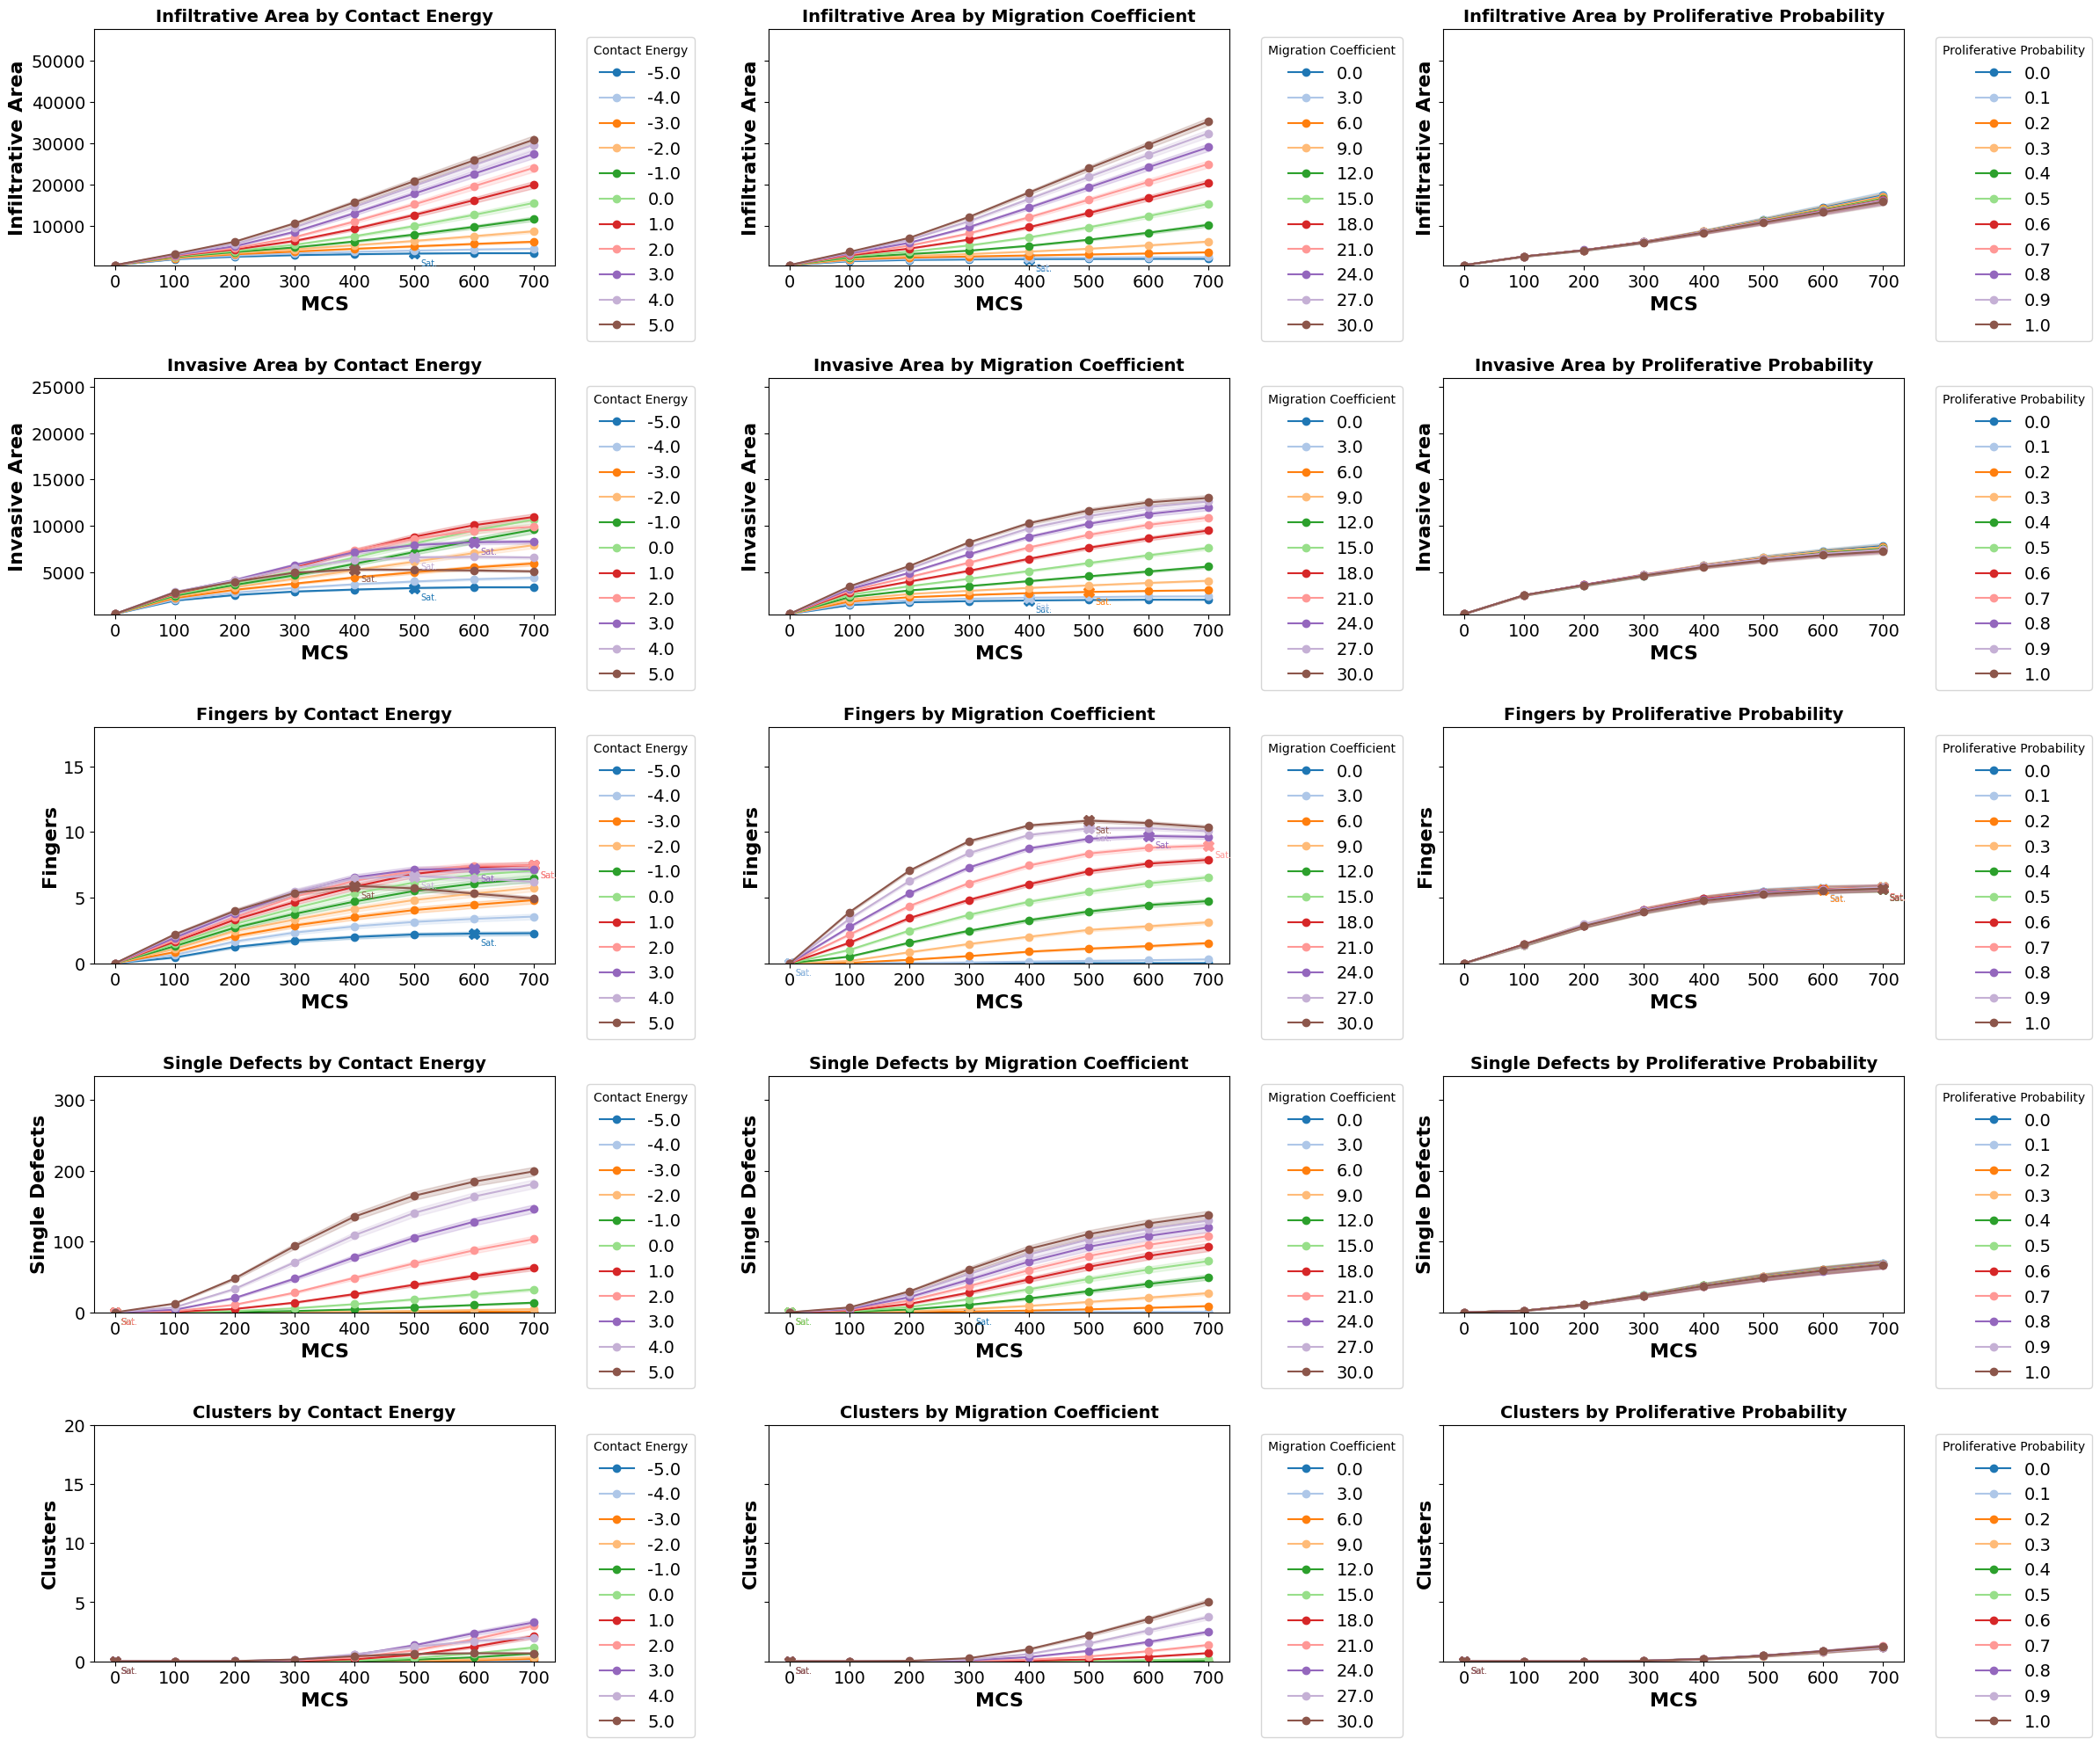

In [66]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === Load all MCS CSV files and append MCS identifier ===
base_path = "../../Results/Data/NEW/Metrics_By_MCS"
file_names = sorted([
    "MCS_0.csv", "MCS_100.csv", "MCS_200.csv", "MCS_300.csv",
    "MCS_400.csv", "MCS_500.csv", "MCS_600.csv", "MCS_700.csv"
])

dfs = []
for file_name in file_names:
    mcs_value = int(file_name.split('_')[1].split('.')[0])
    df = pd.read_csv(os.path.join(base_path, file_name))
    df["MCS"] = mcs_value
    dfs.append(df)

# === Combine all data into a single DataFrame ===
combined_df = pd.concat(dfs, ignore_index=True)
combined_df = combined_df.rename(columns={"Chemotaxis Lambda": "Migration Coefficient"})

# === Define parameters and metrics ===
key_params = ["Contact Energy", "Migration Coefficient", "Proliferative Probability"]
selected_metrics = ["Infiltrative Area", "Invasive Area", "Fingers", "Single Defects", "Clusters"]

# === Create palettes and hue orders ===
palettes = {}
hue_orders = {}
for param in key_params:
    unique_vals = sorted(combined_df[param].unique())
    hue_orders[param] = unique_vals
    palettes[param] = dict(zip(unique_vals, sns.color_palette("tab20", len(unique_vals))))

# === FONT CONFIGURATION ===
title_font = {'fontsize': 14, 'fontweight': 'bold'}
label_font = {'fontsize': 16, 'fontweight': 'bold'}
tick_fontsize = 14

# === === 1. FACET GRID OF ALL SUBPLOTS === ===
fig, axes = plt.subplots(len(selected_metrics), len(key_params), figsize=(24, 20), sharey='row')
for i, metric in enumerate(selected_metrics):
    y_min = combined_df[metric].min()
    y_max = combined_df[metric].max()

    for j, param in enumerate(key_params):
        ax = axes[i, j]
        grouped = combined_df.groupby(["MCS", param])[metric]
        summary = grouped.agg(['mean', 'count', 'std']).reset_index()
        summary["sem"] = summary["std"] / summary["count"]**0.5
        summary["ci95"] = 1.96 * summary["sem"]
        summary.columns = ["MCS", "Parameter", "Mean", "N", "Std", "SEM", "CI95"]

        for key, grp in summary.groupby("Parameter"):
            color = palettes[param][key]
            ax.plot(grp["MCS"], grp["Mean"], marker='o', label=f"{key}", color=color)
            ax.fill_between(grp["MCS"], grp["Mean"] - grp["CI95"], grp["Mean"] + grp["CI95"],
                            alpha=0.2, color=color)

            growth = np.gradient(grp["Mean"].values)
            saturation_idx = np.where(growth < 0.1 * max(growth))[0]
            if len(saturation_idx) > 0:
                sat_mcs = grp["MCS"].iloc[saturation_idx[0]]
                sat_val = grp["Mean"].iloc[saturation_idx[0]]
                ax.plot(sat_mcs, sat_val, 'X', color=color, markersize=8)
                ax.annotate("Sat.", (sat_mcs, sat_val), textcoords="offset points", xytext=(5, -10),
                            ha='left', fontsize=7, color=color)

        ax.set_ylim(y_min, y_max)
        ax.set_title(f"{metric} by {param}", **title_font)
        ax.set_xlabel("MCS", **label_font)
        ax.set_ylabel(metric, **label_font)
        ax.tick_params(axis='both', labelsize=tick_fontsize)
        ax.get_yaxis().set_visible(True)
        ax.legend(title=param, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14)

plt.tight_layout()
facet_output_dir = "../../Results/Plots/Over_Time/metric_trajectories"
os.makedirs(facet_output_dir, exist_ok=True)
fig.savefig(os.path.join(facet_output_dir, "facet_metric_trajectories.png"), dpi=300, bbox_inches='tight')
plt.show()

# === === 2. EXPORT INDIVIDUAL METRIC ROWS === ===
row_output_dir = os.path.join(facet_output_dir, "individual_rows")
os.makedirs(row_output_dir, exist_ok=True)

for i, metric in enumerate(selected_metrics):
    y_min = combined_df[metric].min()
    y_max = combined_df[metric].max()

    fig_row, axes_row = plt.subplots(1, len(key_params), figsize=(24, 5), sharey=False)

    for j, param in enumerate(key_params):
        ax = axes_row[j]
        grouped = combined_df.groupby(["MCS", param])[metric]
        summary = grouped.agg(['mean', 'count', 'std']).reset_index()
        summary["sem"] = summary["std"] / summary["count"]**0.5
        summary["ci95"] = 1.96 * summary["sem"]
        summary.columns = ["MCS", "Parameter", "Mean", "N", "Std", "SEM", "CI95"]

        for key, grp in summary.groupby("Parameter"):
            color = palettes[param][key]
            ax.plot(grp["MCS"], grp["Mean"], marker='o', label=f"{key}", color=color)
            ax.fill_between(grp["MCS"], grp["Mean"] - grp["CI95"], grp["Mean"] + grp["CI95"],
                            alpha=0.2, color=color)

            growth = np.gradient(grp["Mean"].values)
            saturation_idx = np.where(growth < 0.1 * max(growth))[0]
            if len(saturation_idx) > 0:
                sat_mcs = grp["MCS"].iloc[saturation_idx[0]]
                sat_val = grp["Mean"].iloc[saturation_idx[0]]
                ax.plot(sat_mcs, sat_val, 'X', color=color, markersize=8)
                ax.annotate("Sat.", (sat_mcs, sat_val), textcoords="offset points", xytext=(5, -10),
                            ha='left', fontsize=7, color=color)

        ax.set_ylim(y_min, y_max)
        ax.set_title(f"{metric} by {param}", **title_font)
        ax.set_xlabel("MCS", **label_font)
        ax.set_ylabel(metric, **label_font)
        ax.tick_params(axis='both', labelsize=tick_fontsize)
        ax.get_yaxis().set_visible(True)
        ax.legend(title=param, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14)

    plt.tight_layout()
    save_path = os.path.join(row_output_dir, f"{metric.replace(' ', '_')}_trajectory_row.png")
    fig_row.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
